# Imports

In [1]:
import numpy as np                      # Álgebra lineal y aleatorios
import pandas as pd                     # Manipulación de DataFrames
import joblib                           # Serialización de modelos
import matplotlib.pyplot as plt         # Visualización estática
import matplotlib.ticker as mticker     # Formateo de ejes
import seaborn as sns                   # Visualización estadística
from sklearn.metrics import (           # Métricas de clasificación
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score, brier_score_loss,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_validate  # Validación cruzada
from sklearn.preprocessing import StandardScaler  # Estandarización para modelo final
from scipy import stats                 # Distribuciones estadísticas (t-Student)
import warnings, os, time               # Utilidades del sistema
import xgboost as xgb                   # Modelo final (re-entrenado)
warnings.filterwarnings('ignore')       # Silenciar warnings irrelevantes

# Estilo visual global
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42                               # Semilla para reproducibilidad
np.random.seed(SEED)                    # Fijar semilla NumPy

# Rutas

In [2]:
BASE = os.path.dirname(os.path.abspath('.'))           # Directorio raíz del proyecto
DATA_DIR = os.path.join(BASE, 'data', 'interim')       # Datos intermedios
MODELS_DIR = os.path.join(BASE, 'notebooks', 'outputs_sprint3', 'models')  # Modelos Sprint 3
OUT_DIR = os.path.join(BASE, 'notebooks', 'outputs_sprint4_comparativo')   # Salidas Sprint 4
os.makedirs(OUT_DIR, exist_ok=True)                    # Crear carpeta si no existe

print(f'DATA_DIR : {DATA_DIR}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'OUT_DIR   : {OUT_DIR}')

DATA_DIR : /workspaces/proyecto-zona-interes-Au/data/interim
MODELS_DIR: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint3/models
OUT_DIR   : /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4_comparativo


# Carga de datos

In [3]:
df_train = pd.read_csv(os.path.join(DATA_DIR, 'data_entrenamiento_balanceado_fe.csv'))  # Carga train
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'data_prueba_fe.csv'))                    # Carga test

# Columnas que NO son features (target, metadatos, coordenadas)
EXCLUDE_COLS = ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']
feature_cols = [c for c in df_test.columns if c not in EXCLUDE_COLS]  # Lista de features

# Separar X e y
X_train = df_train[feature_cols]        # Features de entrenamiento
y_train = df_train['target_Au']         # Target de entrenamiento
X_test  = df_test[feature_cols]         # Features de prueba
y_test  = df_test['target_Au']          # Target de prueba

print(f'Train: {X_train.shape} | Target dist: {y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape}  | Target dist: {y_test.value_counts().to_dict()}')
print(f'Features ({len(feature_cols)}): {feature_cols[:5]} ... {feature_cols[-5:]}')

Train: (2994, 57) | Target dist: {0: 1497, 1: 1497}
Test : (427, 57)  | Target dist: {0: 375, 1: 52}
Features (57): ['Ag_ppm', 'Al_per', 'As_ppm', 'Ba_ppm', 'Be_ppm'] ... ['Pb_Zn_ratio', 'Bi_As_ratio', 'pathfinder_sum', 'pathfinder_mean', 'pathfinder_max']


# Carga de modelos

In [4]:
# Baseline: Random Forest sin tuning + Feature Engineering
model_baseline = joblib.load(os.path.join(MODELS_DIR, 'sprint3_rf_baseline_fe.pkl'))
scaler_baseline = joblib.load(os.path.join(MODELS_DIR, 'sprint3_rf_baseline_fe_scaler.pkl'))

# Modelo actual: XGBoost optimizado con Optuna (cargado desde sprint3)
model_actual = joblib.load(os.path.join(MODELS_DIR, 'sprint3_xgboost_optuna.pkl'))
scaler_actual = joblib.load(os.path.join(MODELS_DIR, 'sprint3_xgboost_optuna_scaler.pkl'))

# RF Tuned: comparación intermedia
model_rf_tuned = joblib.load(os.path.join(MODELS_DIR, 'sprint3_randomforest_tuned.pkl'))
scaler_rf_tuned = joblib.load(os.path.join(MODELS_DIR, 'sprint3_randomforest_tuned_scaler.pkl'))

print('Modelos cargados exitosamente:')
print(f'  Baseline  : {type(model_baseline).__name__} (n_estimators={model_baseline.n_estimators})')
print(f'  RF Tuned  : {type(model_rf_tuned).__name__} (n_estimators={model_rf_tuned.n_estimators}, max_depth={model_rf_tuned.max_depth})')
print(f'  XGB Optuna: {type(model_actual).__name__} (n_estimators={model_actual.n_estimators}, max_depth={model_actual.max_depth})')

Modelos cargados exitosamente:
  Baseline  : RandomForestClassifier (n_estimators=100)
  RF Tuned  : RandomForestClassifier (n_estimators=40, max_depth=11)
  XGB Optuna: XGBClassifier (n_estimators=300, max_depth=8)


# Predicciones en conjunto de prueba

In [5]:
modelos = {
    'RF Baseline (FE)': (model_baseline, scaler_baseline),
    'RF Tuned (FE)':    (model_rf_tuned, scaler_rf_tuned),
    'XGBoost Optuna':   (model_actual, scaler_actual),
}

resultados_pred = {}  # Diccionario para almacenar predicciones y probabilidades
for nombre, (modelo, scaler) in modelos.items():
    X_scaled = scaler.transform(X_test)                       # Estandarizar test
    y_pred = modelo.predict(X_scaled)                           # Clase predicha
    y_prob = modelo.predict_proba(X_scaled)[:, 1]             # Probabilidad clase positiva
    resultados_pred[nombre] = {'y_pred': y_pred, 'y_prob': y_prob}
    print(f'{nombre}: Positivos predichos = {y_pred.sum()}/{len(y_pred)}')

RF Baseline (FE): Positivos predichos = 42/427
RF Tuned (FE): Positivos predichos = 43/427
XGBoost Optuna: Positivos predichos = 48/427


# Modelo final XGBOOST optuna + Mitigación

In [6]:
# El sprint4.ipynb NO usa el pkl del sprint3; entrena su propio XGBoost desde cero
# con los mismos hiperparámetros y SEED=42. Aquí se reproduce exactamente eso.

from sklearn.preprocessing import StandardScaler as _SC  # Alias para evitar conflicto

# 1) Re-entrenar XGBoost con los mismos hiperparámetros del sprint4
xgb_params_s4 = {
    'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3,
    'random_state': SEED, 'eval_metric': 'aucpr', 'tree_method': 'hist',
}

scaler_s4 = _SC()                       # Instanciar scaler local
X_train_s4 = scaler_s4.fit_transform(X_train)  # Ajustar y transformar train
X_test_s4  = scaler_s4.transform(X_test)       # Transformar test

model_s4 = xgb.XGBClassifier(**xgb_params_s4)    # Crear modelo XGBoost
model_s4.fit(X_train_s4, y_train)               # Entrenar modelo

y_prob_s4 = model_s4.predict_proba(X_test_s4)[:, 1]  # Probabilidades sprint4
y_pred_s4 = (y_prob_s4 >= 0.5).astype(int)           # Predicciones con umbral 0.5
f1_base_s4 = f1_score(y_test, y_pred_s4)            # F1 base sprint4
print(f'F1 XGBoost sprint4 (umbral 0.5, sin mitigación): {f1_base_s4:.4f}')

# 2) Slices problemáticos (definiciones idénticas al sprint4.ipynb)
df_test_orig = pd.read_csv(os.path.join(DATA_DIR, 'data_prueba.csv'))  # Carga original sin FE

# DataFrame auxiliar con coordenadas para slices
df_slices = pd.DataFrame({
    'East':  df_test_orig['East'].values[:len(df_test)],   # Coordenada Este
    'North': df_test_orig['North'].values[:len(df_test)],  # Coordenada Norte
    'Level': df_test_orig['Level'].values[:len(df_test)],   # Nivel
})

# Medianas para cuadrantes
east_med, north_med = df_slices['East'].median(), df_slices['North'].median()

def _cuadrante(r):
    """Asigna cuadrante geográfico según medianas."""
    if r['East'] >= east_med and r['North'] >= north_med: return 'NE'
    if r['East'] <  east_med and r['North'] >= north_med: return 'NO'
    if r['East'] <  east_med and r['North'] <  north_med: return 'SO'
    return 'SE'

df_slices['slice_cuadrante'] = df_slices.apply(_cuadrante, axis=1)  # Crear columna cuadrante

# Cuantiles para profundidad
lq33, lq66 = df_slices['Level'].quantile(0.33), df_slices['Level'].quantile(0.66)
df_slices['slice_profundidad'] = df_slices['Level'].apply(
    lambda v: 'Superficial' if v <= lq33 else ('Medio' if v <= lq66 else 'Profundo'))

# 3) Umbral óptimo por slice (maximiza F1)
def find_optimal_threshold(y_true, y_prob):
    """Busca umbral que maximiza F1 en un slice."""
    best_s, best_t = -1, 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        s = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if s > best_s:
            best_s, best_t = s, t
    return best_t, best_s

y_pred_mitA = y_pred_s4.copy()          # Copiar predicciones base
slices_problematicos = [('slice_profundidad', 'Profundo'), ('slice_cuadrante', 'NE')]  # Slices a mitigar
for col, cat in slices_problematicos:
    pos = np.where((df_slices[col] == cat).values)[0]  # Índices del slice
    if len(pos) >= 10 and len(np.unique(y_test.values[pos])) == 2:
        t_opt, f1_opt = find_optimal_threshold(y_test.values[pos], y_prob_s4[pos])
        y_pred_mitA[pos] = (y_prob_s4[pos] >= t_opt).astype(int)  # Aplicar umbral óptimo
        print(f'Slice {cat:10s}: umbral óptimo = {t_opt:.2f} (F1 slice = {f1_opt:.4f}, n={len(pos)})')

# 4) Agregar al comparativo
resultados_pred['XGB Optuna + Mit. A'] = {'y_pred': y_pred_mitA, 'y_prob': y_prob_s4}

f1_con = f1_score(y_test, y_pred_mitA)  # F1 con mitigación
print(f'\nF1 sin mitigación : {f1_base_s4:.4f}')
print(f'F1 con Mitigación A: {f1_con:.4f} (Δ = {f1_con - f1_base_s4:+.4f})')

F1 XGBoost sprint4 (umbral 0.5, sin mitigación): 0.9515
Slice Profundo  : umbral óptimo = 0.56 (F1 slice = 0.9000, n=145)
Slice NE        : umbral óptimo = 0.20 (F1 slice = 1.0000, n=111)

F1 sin mitigación : 0.9515
F1 con Mitigación A: 0.9808 (Δ = +0.0293)


# Funcion de evaluación global con BOOTSTRAP IC 95%

In [7]:
def evaluar_global_bootstrap(y_true, y_prob, y_pred, n_boot=1000, conf=0.95, seed=42):
    """
    Evaluación global con bootstrap para calcular intervalos de confianza robustos.
    Retorna dict con métricas puntuales + IC para F1, Precision, Recall, PR-AUC, ROC-AUC, Brier.
    """
    rng = np.random.RandomState(seed)      # Generador reproducible
    n = len(y_true)                        # Tamaño de la muestra
    alpha = (1 - conf) / 2                 # Cola inferior (ej: 0.025 para 95%)

    # Métricas puntuales (valores exactos sobre el conjunto completo)
    metrics = {
        'n': n,
        'n_pos': int(y_true.sum()),
        'n_neg': int((1 - y_true).sum()),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'PR_AUC':    average_precision_score(y_true, y_prob),
        'ROC_AUC':   roc_auc_score(y_true, y_prob),
        'Brier':     brier_score_loss(y_true, y_prob),
    }

    # Bootstrap: remuestreo con reemplazo
    boot_metrics = {k: [] for k in ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Brier']}
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)  # Índices aleatorios con repetición
        yt = np.array(y_true)[idx]
        yp = np.array(y_pred)[idx]
        ypr = np.array(y_prob)[idx]

        if len(np.unique(yt)) < 2:  # Evitar división por cero si solo una clase
            continue

        boot_metrics['F1'].append(f1_score(yt, yp, zero_division=0))
        boot_metrics['Precision'].append(precision_score(yt, yp, zero_division=0))
        boot_metrics['Recall'].append(recall_score(yt, yp, zero_division=0))
        boot_metrics['PR_AUC'].append(average_precision_score(yt, ypr))
        boot_metrics['ROC_AUC'].append(roc_auc_score(yt, ypr))
        boot_metrics['Brier'].append(brier_score_loss(yt, ypr))

    # Calcular percentiles para IC
    for key in boot_metrics:
        vals = np.array(boot_metrics[key])
        if len(vals) > 0:
            metrics[f'{key}_CI_low']  = np.percentile(vals, alpha * 100)
            metrics[f'{key}_CI_high'] = np.percentile(vals, (1 - alpha) * 100)
            metrics[f'{key}_std']     = np.std(vals)
        else:
            metrics[f'{key}_CI_low'] = metrics[f'{key}_CI_high'] = metrics[f'{key}_std'] = np.nan

    return metrics

print('Función evaluar_global_bootstrap() definida')

Función evaluar_global_bootstrap() definida


# Evaluación en Hold-out con IC 95%

In [8]:
eval_results = {}
for nombre, preds in resultados_pred.items():
    print(f'Evaluando {nombre} (bootstrap n=1000)...')
    eval_results[nombre] = evaluar_global_bootstrap(
        y_test.values, preds['y_prob'], preds['y_pred'],
        n_boot=1000, seed=SEED
    )
print('\nEvaluación completada ok')

# Tabla comparativa principal (valor + IC)
metricas_clave = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC', 'Brier']
rows = []
for nombre in resultados_pred.keys():
    r = eval_results[nombre]
    row = {'Modelo': nombre}
    for m in metricas_clave:
        row[m] = f"{r[m]:.4f}"
        row[f'{m}_IC95'] = f"[{r[f'{m}_CI_low']:.4f}, {r[f'{m}_CI_high']:.4f}]"
    rows.append(row)

df_comp = pd.DataFrame(rows)
print('\n=== COMPARATIVO HOLD-OUT CON IC 95% (Bootstrap n=1000) ===')
print(f'Conjunto de prueba: n={len(y_test)} (positivos={y_test.sum()}, negativos={(1-y_test).sum()})\n')
print(df_comp.to_string(index=False))

# Tabla compacta: valor +- std [IC]
rows_compact = []
for nombre in resultados_pred.keys():
    r = eval_results[nombre]
    row = {'Modelo': nombre}
    for m in metricas_clave:
        row[m] = f"{r[m]:.4f} +- {r[f'{m}_std']:.4f}"
        row[f'{m} IC95'] = f"[{r[f'{m}_CI_low']:.4f}, {r[f'{m}_CI_high']:.4f}]"
    rows_compact.append(row)

df_compact = pd.DataFrame(rows_compact)
df_compact.to_csv(os.path.join(OUT_DIR, 'comparativo_holdout_ic95.csv'), index=False)
print('\nTabla guardada en outputs_sprint4_comparativo/comparativo_holdout_ic95.csv')
print(df_compact.to_string(index=False))

Evaluando RF Baseline (FE) (bootstrap n=1000)...
Evaluando RF Tuned (FE) (bootstrap n=1000)...
Evaluando XGBoost Optuna (bootstrap n=1000)...
Evaluando XGB Optuna + Mit. A (bootstrap n=1000)...

Evaluación completada ok

=== COMPARATIVO HOLD-OUT CON IC 95% (Bootstrap n=1000) ===
Conjunto de prueba: n=427 (positivos=52, negativos=375)

             Modelo     F1          F1_IC95 Precision   Precision_IC95 Recall      Recall_IC95 PR_AUC      PR_AUC_IC95 ROC_AUC     ROC_AUC_IC95  Brier       Brier_IC95
   RF Baseline (FE) 0.8723 [0.7907, 0.9383]    0.9762 [0.9230, 1.0000] 0.7885 [0.6756, 0.8966] 0.9717 [0.9419, 0.9920]  0.9961 [0.9923, 0.9989] 0.0233 [0.0171, 0.0301]
      RF Tuned (FE) 0.8842 [0.8085, 0.9495]    0.9767 [0.9250, 1.0000] 0.8077 [0.6949, 0.9149] 0.9750 [0.9479, 0.9958]  0.9950 [0.9884, 0.9994] 0.0224 [0.0160, 0.0297]
     XGBoost Optuna 0.9400 [0.8864, 0.9815]    0.9792 [0.9318, 1.0000] 0.9038 [0.8182, 0.9792] 0.9874 [0.9689, 0.9985]  0.9978 [0.9948, 0.9998] 0.0108 [0.0053,

# Validación cruzada 5-FOLD con IC 95% (t-Student)

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)  # Validación cruzada estratificada
scoring = ['f1', 'precision', 'recall', 'roc_auc', 'average_precision']  # Métricas a evaluar

cv_results = {}
for nombre, (modelo, scaler) in modelos.items():
    print(f'CV 5-fold para {nombre}...')
    X_scaled = scaler.transform(X_train)  # Estandarizar train para CV
    cv_out = cross_validate(modelo, X_scaled, y_train, cv=cv, scoring=scoring, return_train_score=False)

    row = {'Modelo': nombre}
    for s in scoring:
        vals = cv_out[f'test_{s}']
        mean, std = vals.mean(), vals.std()
        t_crit = stats.t.ppf(0.975, df=len(vals)-1)  # t crítico para 95% con 4 grados de libertad
        se = std / np.sqrt(len(vals))
        ci_low = mean - t_crit * se
        ci_high = mean + t_crit * se

        row[f'{s}_mean'] = mean
        row[f'{s}_std'] = std
        row[f'{s}_IC95'] = f"[{ci_low:.4f}, {ci_high:.4f}]"
        row[f'{s}_display'] = f"{mean:.4f} +- {std:.4f}"
    cv_results[nombre] = row

df_cv = pd.DataFrame(cv_results.values())
df_cv.to_csv(os.path.join(OUT_DIR, 'comparativo_cv_ic95.csv'), index=False)
print('\n=== VALIDACIÓN CRUZADA 5-FOLD CON IC 95% (t-Student) ===')
print(df_cv.to_string(index=False))

CV 5-fold para RF Baseline (FE)...


CV 5-fold para RF Tuned (FE)...
CV 5-fold para XGBoost Optuna...

=== VALIDACIÓN CRUZADA 5-FOLD CON IC 95% (t-Student) ===
          Modelo  f1_mean   f1_std          f1_IC95       f1_display  precision_mean  precision_std   precision_IC95 precision_display  recall_mean  recall_std      recall_IC95   recall_display  roc_auc_mean  roc_auc_std     roc_auc_IC95  roc_auc_display  average_precision_mean  average_precision_std average_precision_IC95 average_precision_display
RF Baseline (FE) 0.988205 0.005948 [0.9808, 0.9956] 0.9882 +- 0.0059        0.995921       0.003971 [0.9910, 1.0009]  0.9959 +- 0.0040     0.980631    0.008815 [0.9697, 0.9916] 0.9806 +- 0.0088      0.999341     0.000631 [0.9986, 1.0001] 0.9993 +- 0.0006                0.999365               0.000591       [0.9986, 1.0001]          0.9994 +- 0.0006
   RF Tuned (FE) 0.985830 0.007132 [0.9770, 0.9947] 0.9858 +- 0.0071        0.994569       0.005531 [0.9877, 1.0014]  0.9946 +- 0.0055     0.977300    0.011238 [0.9633, 0.9913

# Visualizaciones comparativas

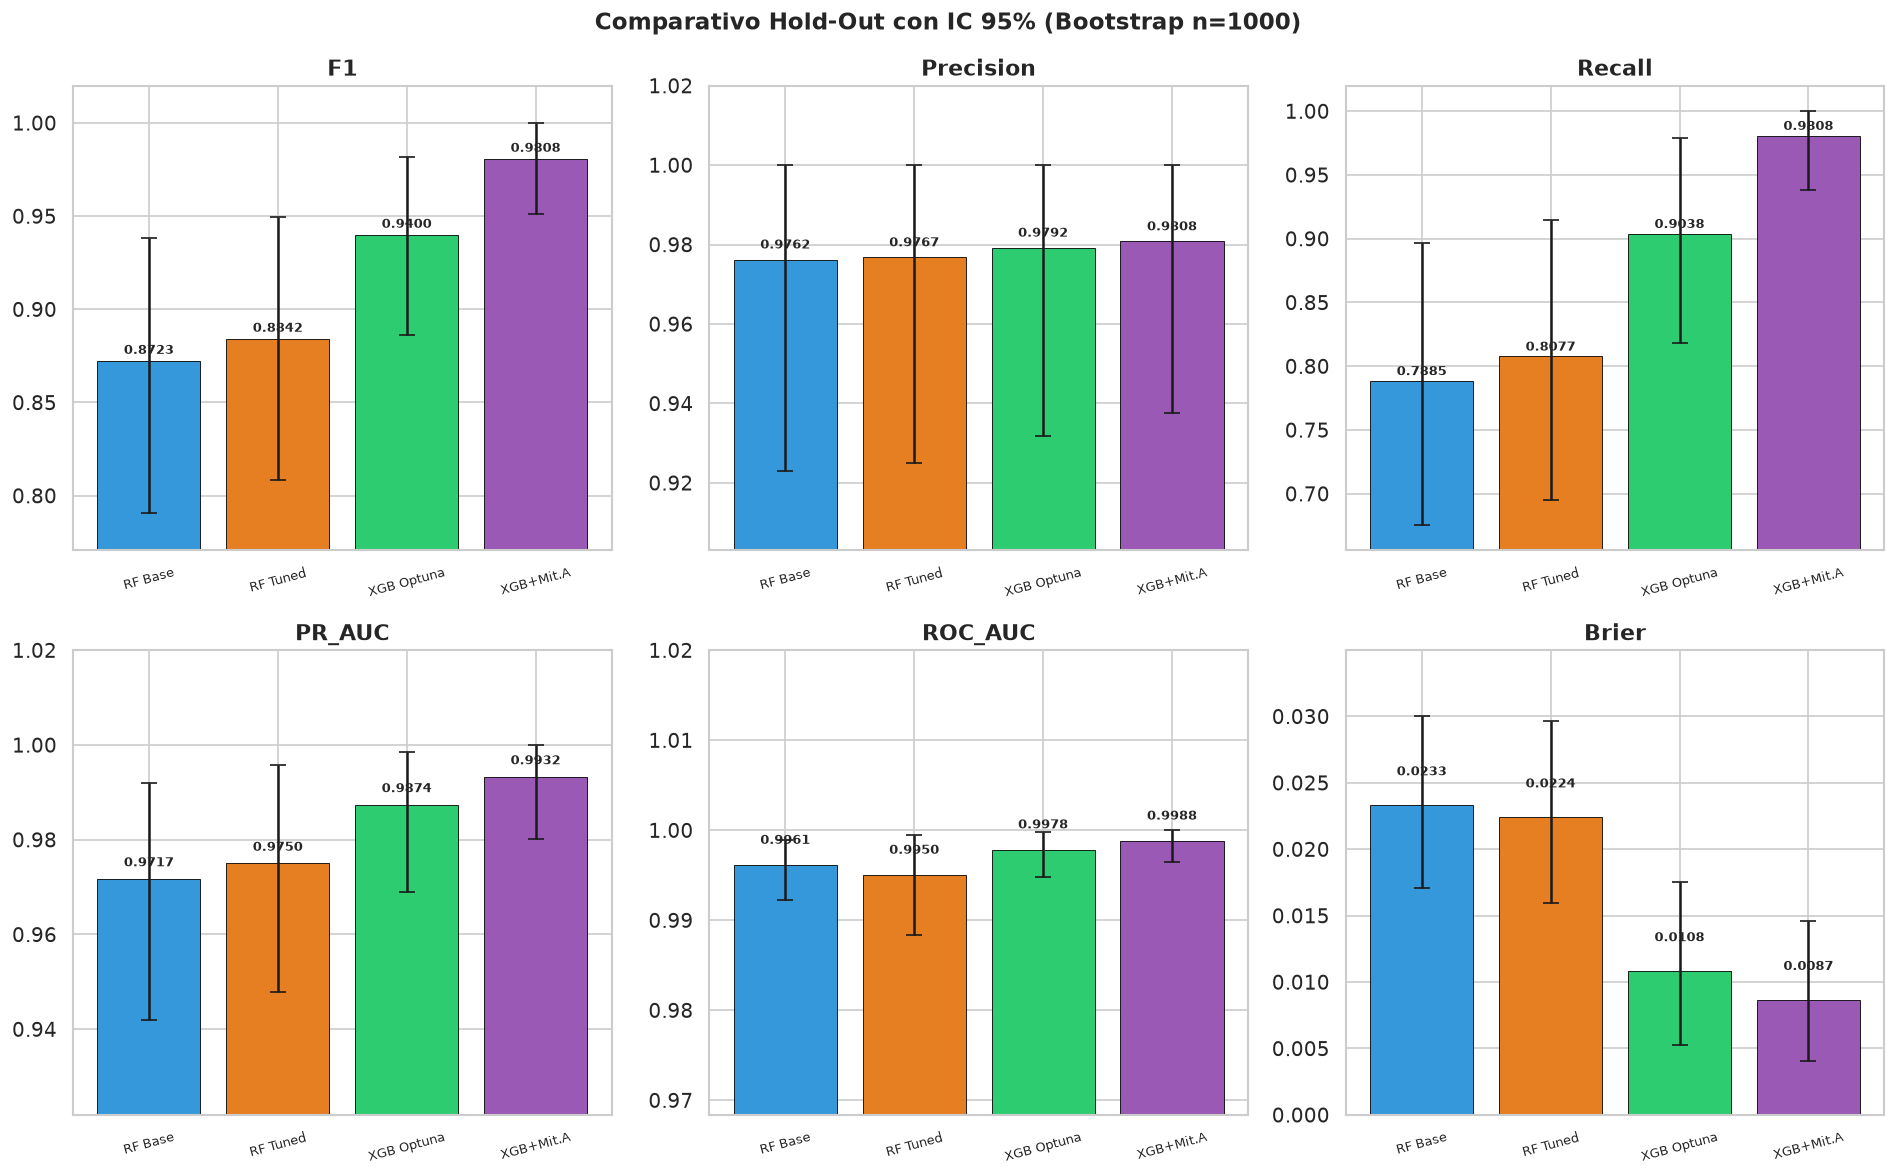

Guardado: comparativo_barras_ic95.png


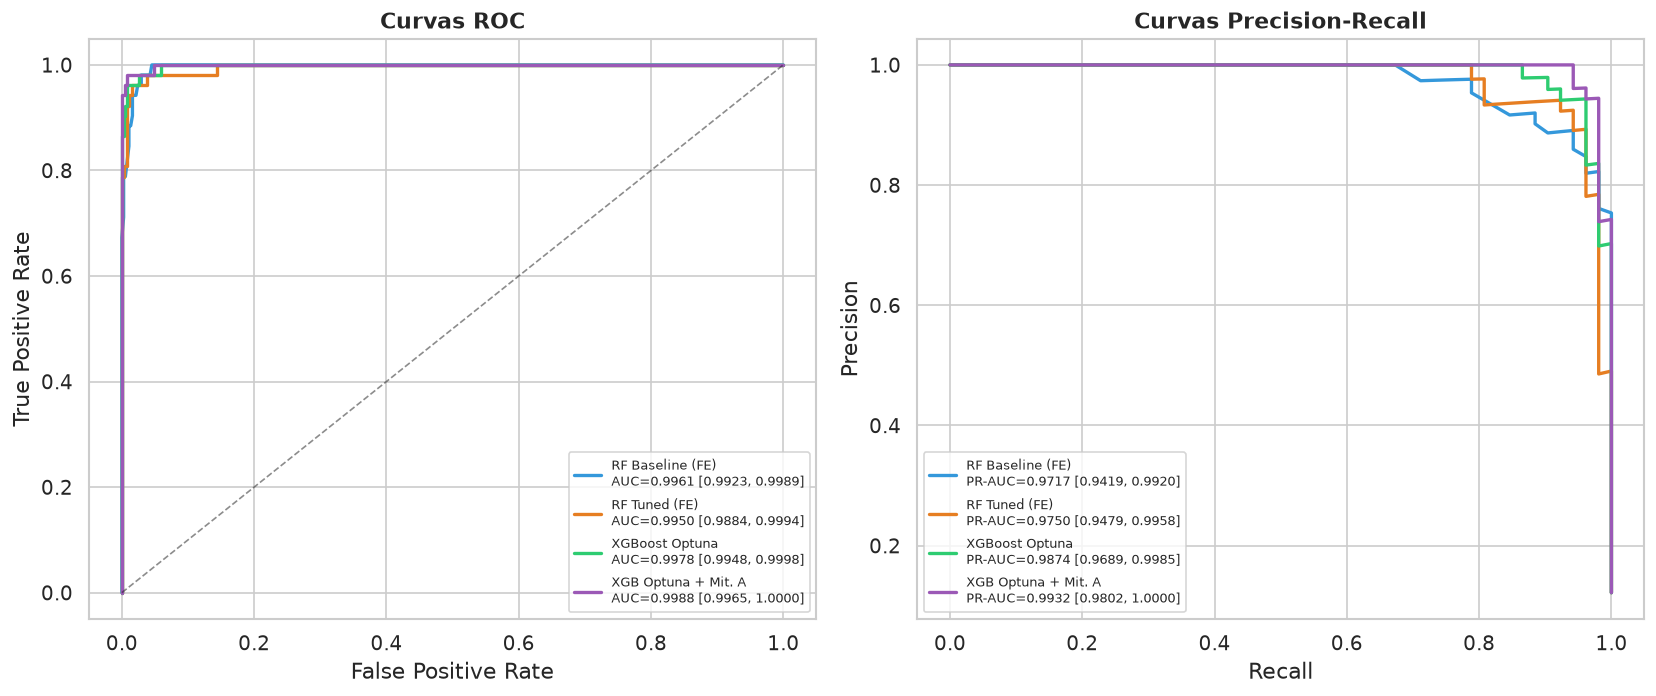

Guardado: curvas_roc_pr_comparativo.png


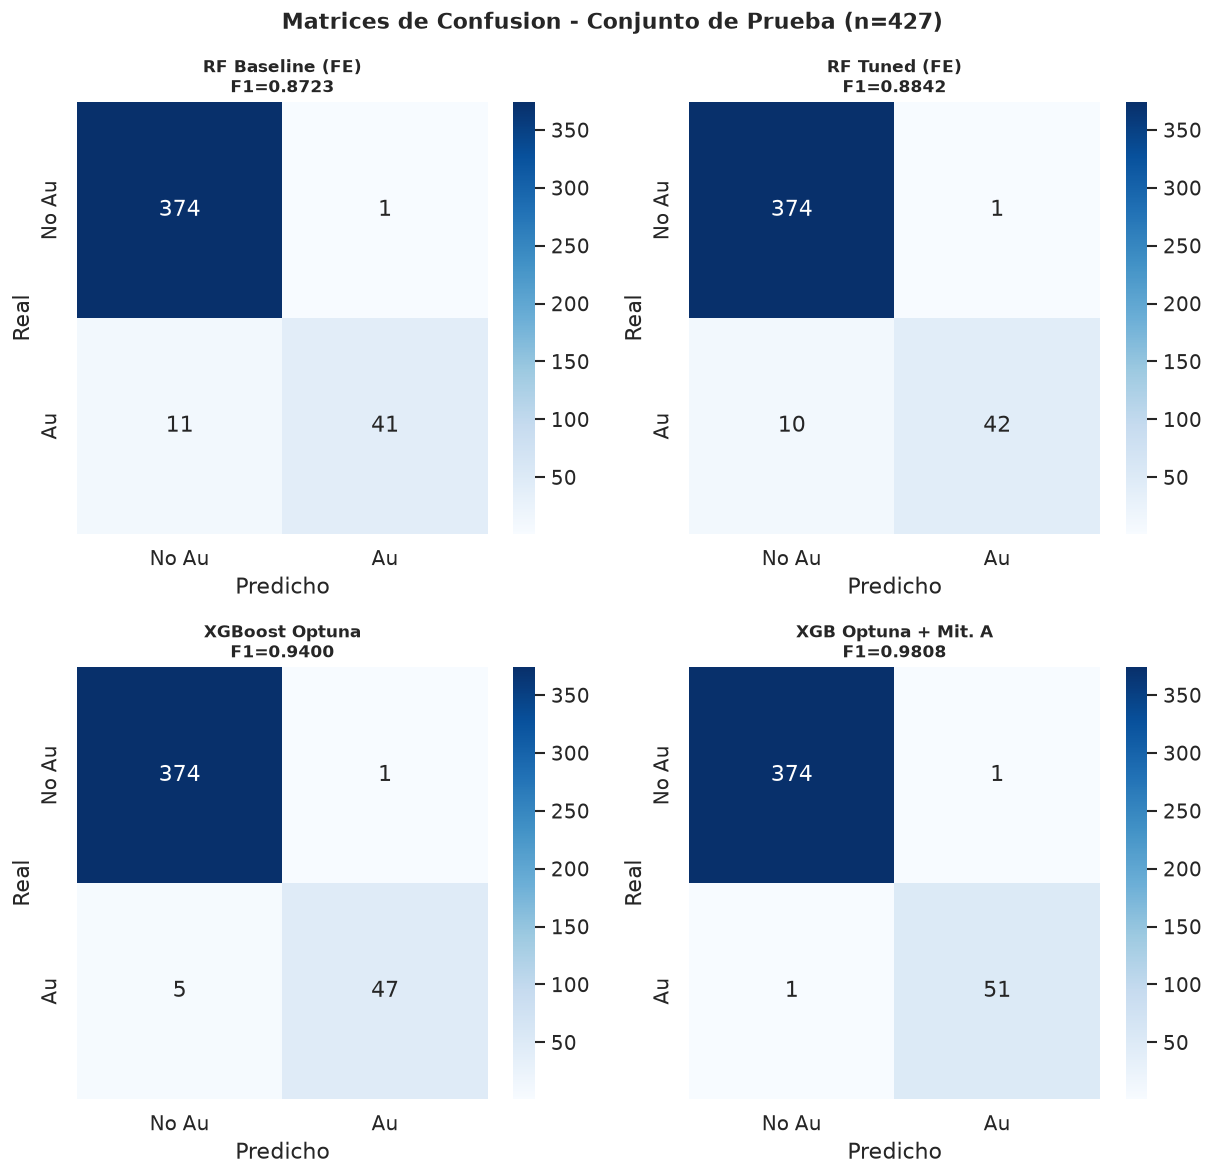

Guardado: matrices_confusion_comparativo.png


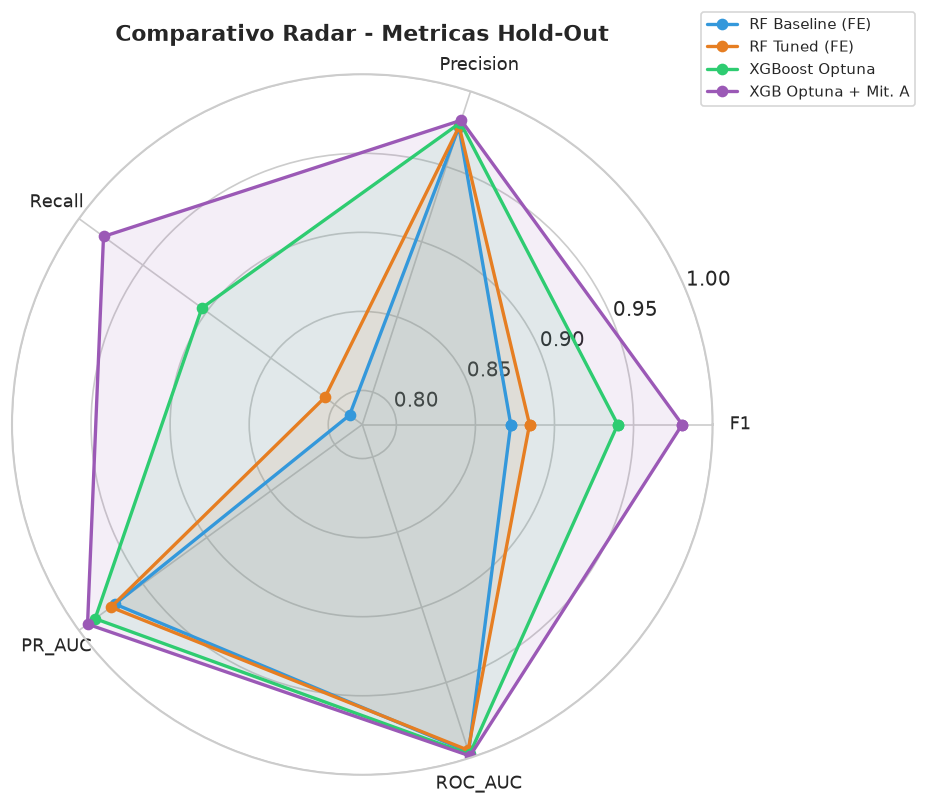

Guardado: radar_comparativo.png


In [10]:
# 1 Grafico de barras con IC 95% - metricas hold-out
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparativo Hold-Out con IC 95% (Bootstrap n=1000)', fontsize=14, fontweight='bold')

colores = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
nombres_modelos = list(resultados_pred.keys())

for idx, metrica in enumerate(metricas_clave):
    ax = axes[idx // 3, idx % 3]
    vals = [eval_results[n][metrica] for n in nombres_modelos]
    ci_lows = [eval_results[n][f'{metrica}_CI_low'] for n in nombres_modelos]
    ci_highs = [eval_results[n][f'{metrica}_CI_high'] for n in nombres_modelos]
    errors_low = [v - cl for v, cl in zip(vals, ci_lows)]
    errors_high = [ch - v for v, ch in zip(vals, ci_highs)]

    bars = ax.bar(range(len(nombres_modelos)), vals, color=colores,
                  yerr=[errors_low, errors_high], capsize=5, edgecolor='black', linewidth=0.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_xticks(range(len(nombres_modelos)))
    ax.set_xticklabels(['RF Base', 'RF Tuned', 'XGB Optuna', 'XGB+Mit.A'], rotation=15, fontsize=8)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    if metrica == 'Brier':
        ax.set_ylim(0, max(vals) * 1.5)
    else:
        ymin = min(ci_lows) - 0.02
        ax.set_ylim(max(0, ymin), 1.02)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'comparativo_barras_ic95.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: comparativo_barras_ic95.png')

# 2 Curvas ROC y Precision-Recall comparativas (todos los modelos)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for nombre, color in zip(nombres_modelos, colores):
    y_prob = resultados_pred[nombre]['y_prob']

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = eval_results[nombre]['ROC_AUC']
    ci_low = eval_results[nombre]['ROC_AUC_CI_low']
    ci_high = eval_results[nombre]['ROC_AUC_CI_high']
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f'{nombre}\nAUC={roc_auc:.4f} [{ci_low:.4f}, {ci_high:.4f}]')

    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = eval_results[nombre]['PR_AUC']
    ci_low_pr = eval_results[nombre]['PR_AUC_CI_low']
    ci_high_pr = eval_results[nombre]['PR_AUC_CI_high']
    ax2.plot(rec, prec, color=color, lw=2,
             label=f'{nombre}\nPR-AUC={pr_auc:.4f} [{ci_low_pr:.4f}, {ci_high_pr:.4f}]')

ax1.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Curvas ROC', fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Curvas Precision-Recall', fontweight='bold')
ax2.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'curvas_roc_pr_comparativo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: curvas_roc_pr_comparativo.png')

# 3 Matrices de confusion lado a lado
n_mod = len(resultados_pred)
fig, axes = plt.subplots(2, 2, figsize=(10.4, 10))
axes = axes.flatten()
fig.suptitle(f'Matrices de Confusion - Conjunto de Prueba (n={len(y_test)})', fontsize=13, fontweight='bold')

for idx, (nombre, preds) in enumerate(resultados_pred.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Au', 'Au'], yticklabels=['No Au', 'Au'])
    f1 = eval_results[nombre]['F1']
    axes[idx].set_title(f'{nombre}\nF1={f1:.4f}', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Predicho')

# Ocultar subplots vacíos si hay menos de 4 modelos
for idx in range(n_mod, 4):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'matrices_confusion_comparativo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: matrices_confusion_comparativo.png')

# 4 Radar chart comparativo
metricas_radar = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']
angles = np.linspace(0, 2*np.pi, len(metricas_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for nombre, color in zip(nombres_modelos, colores):
    vals = [eval_results[nombre][m] for m in metricas_radar]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', color=color, linewidth=2, label=nombre)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metricas_radar, fontsize=11)
# Escala dinamica
all_vals = [eval_results[n][m] for n in nombres_modelos for m in metricas_radar]
ymin = max(0.0, min(all_vals) - 0.01)
ax.set_ylim(ymin, 1.0)
ax.set_rlabel_position(22.5)
ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
ax.set_title('Comparativo Radar - Metricas Hold-Out', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'radar_comparativo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: radar_comparativo.png')

# Análisis de ganancia: Baseline -> Actual

=== GANANCIA: Baseline -> XGB Optuna + Mitigacion A ===
  Metrica Baseline (RF) Actual (XGB + Mit. A) Delta Absoluto Delta Relativo (%)  IC 95% Baseline    IC 95% Actual
       F1        0.8723                0.9808        +0.1084            +12.43% [0.7907, 0.9383] [0.9512, 1.0000]
Precision        0.9762                0.9808        +0.0046             +0.47% [0.9230, 1.0000] [0.9375, 1.0000]
   Recall        0.7885                0.9808        +0.1923            +24.39% [0.6756, 0.8966] [0.9384, 1.0000]
   PR_AUC        0.9717                0.9932        +0.0215             +2.22% [0.9419, 0.9920] [0.9802, 1.0000]
  ROC_AUC        0.9961                0.9988        +0.0027             +0.27% [0.9923, 0.9989] [0.9965, 1.0000]
    Brier        0.0233                0.0087        -0.0147            -62.83% [0.0171, 0.0301] [0.0041, 0.0146]


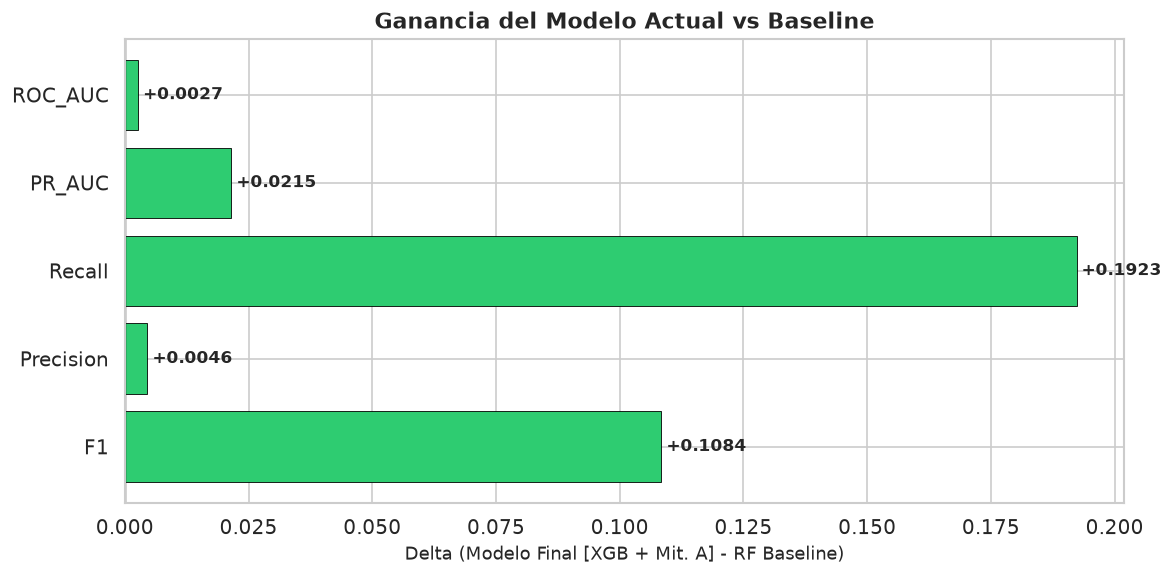

Guardado: delta_ganancia.png


In [11]:
# Delta entre Baseline y el MODELO FINAL (XGB Optuna + Mitigacion A)
baseline_name = 'RF Baseline (FE)'
actual_name   = 'XGB Optuna + Mit. A'

rows_delta = []
for m in metricas_clave:
    val_bl = eval_results[baseline_name][m]
    val_act = eval_results[actual_name][m]
    delta = val_act - val_bl
    pct = (delta / val_bl * 100) if val_bl != 0 else 0
    rows_delta.append({
        'Metrica': m,
        'Baseline (RF)': f'{val_bl:.4f}',
        'Actual (XGB + Mit. A)': f'{val_act:.4f}',
        'Delta Absoluto': f'{delta:+.4f}',
        'Delta Relativo (%)': f'{pct:+.2f}%',
        'IC 95% Baseline': f"[{eval_results[baseline_name][f'{m}_CI_low']:.4f}, {eval_results[baseline_name][f'{m}_CI_high']:.4f}]",
        'IC 95% Actual': f"[{eval_results[actual_name][f'{m}_CI_low']:.4f}, {eval_results[actual_name][f'{m}_CI_high']:.4f}]",
    })

df_delta = pd.DataFrame(rows_delta)
df_delta.to_csv(os.path.join(OUT_DIR, 'delta_baseline_vs_actual.csv'), index=False)
print('=== GANANCIA: Baseline -> XGB Optuna + Mitigacion A ===')
print(df_delta.to_string(index=False))

# Grafico de deltas
fig, ax = plt.subplots(figsize=(10, 5))
metricas_plot = ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']
deltas = [eval_results[actual_name][m] - eval_results[baseline_name][m] for m in metricas_plot]
colors_bar = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]

bars = ax.barh(metricas_plot, deltas, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Delta (Modelo Final [XGB + Mit. A] - RF Baseline)', fontsize=11)
ax.set_title('Ganancia del Modelo Actual vs Baseline', fontweight='bold', fontsize=13)

for bar, d in zip(bars, deltas):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{d:+.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'delta_ganancia.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: delta_ganancia.png')

# Tabla consolidada

In [12]:
consolidado = {
    'Metrica': [], 'Baseline (RF)': [],
    'Actual (XGB + Mit. A)': [], 'Delta': [], 'Veredicto': []
}

for m in ['F1', 'Precision', 'Recall', 'PR_AUC', 'ROC_AUC']:
    val_bl = eval_results[baseline_name][m]
    val_act = eval_results[actual_name][m]
    delta = val_act - val_bl
    consolidado['Metrica'].append(m)
    consolidado['Baseline (RF)'].append(f'{val_bl:.4f} [{eval_results[baseline_name][f"{m}_CI_low"]:.4f}, {eval_results[baseline_name][f"{m}_CI_high"]:.4f}]')
    consolidado['Actual (XGB + Mit. A)'].append(f'{val_act:.4f} [{eval_results[actual_name][f"{m}_CI_low"]:.4f}, {eval_results[actual_name][f"{m}_CI_high"]:.4f}]')
    consolidado['Delta'].append(f'{delta:+.4f}')
    consolidado['Veredicto'].append('Mejora' if delta > 0 else 'Sin cambio' if delta == 0 else 'Peor')

# Brier (menor = mejor)
val_bl = eval_results[baseline_name]['Brier']
val_act = eval_results[actual_name]['Brier']
delta = val_act - val_bl
consolidado['Metrica'].append('Brier Score')
consolidado['Baseline (RF)'].append(f'{val_bl:.4f}')
consolidado['Actual (XGB + Mit. A)'].append(f'{val_act:.4f}')
consolidado['Delta'].append(f'{delta:+.4f}')
consolidado['Veredicto'].append('Mejora' if delta < 0 else 'Sin cambio' if delta == 0 else 'Peor')

df_consolidado = pd.DataFrame(consolidado)
df_consolidado.to_csv(os.path.join(OUT_DIR, 'tabla_consolidada_final.csv'), index=False)

print('='*80)
print('TABLA CONSOLIDADA: BASELINE vs MODELO FINAL (XGBoost + Mitigacion A)')
print('='*80)
print(df_consolidado.to_string(index=False))

TABLA CONSOLIDADA: BASELINE vs MODELO FINAL (XGBoost + Mitigacion A)
    Metrica           Baseline (RF)   Actual (XGB + Mit. A)   Delta Veredicto
         F1 0.8723 [0.7907, 0.9383] 0.9808 [0.9512, 1.0000] +0.1084    Mejora
  Precision 0.9762 [0.9230, 1.0000] 0.9808 [0.9375, 1.0000] +0.0046    Mejora
     Recall 0.7885 [0.6756, 0.8966] 0.9808 [0.9384, 1.0000] +0.1923    Mejora
     PR_AUC 0.9717 [0.9419, 0.9920] 0.9932 [0.9802, 1.0000] +0.0215    Mejora
    ROC_AUC 0.9961 [0.9923, 0.9989] 0.9988 [0.9965, 1.0000] +0.0027    Mejora
Brier Score                  0.0233                  0.0087 -0.0147    Mejora


# Resumen

In [13]:
bl = eval_results[baseline_name]
act = eval_results[actual_name]

# Significancia: los IC 95% de F1 NO se solapan
f1_significativo = act['F1_CI_low'] > bl['F1_CI_high']

print('='*70)
print('RESUMEN EJECUTIVO - COMPARATIVO BASELINE vs MODELO FINAL')
print('='*70)
print('')
print('1. MEJORA TECNICA (hold-out):')
print(f'   - F1-Score:  {bl["F1"]:.4f} -> {act["F1"]:.4f} (Delta = {act["F1"]-bl["F1"]:+.4f})')
print(f'   - Precision: {bl["Precision"]:.4f} -> {act["Precision"]:.4f} (Delta = {act["Precision"]-bl["Precision"]:+.4f})')
print(f'   - Recall:    {bl["Recall"]:.4f} -> {act["Recall"]:.4f} (Delta = {act["Recall"]-bl["Recall"]:+.4f})')
print(f'   - PR-AUC:    {bl["PR_AUC"]:.4f} -> {act["PR_AUC"]:.4f} (Delta = {act["PR_AUC"]-bl["PR_AUC"]:+.4f})')
print('')
print('2. SIGNIFICANCIA ESTADISTICA:')
print(f'   - IC 95% F1 Baseline: [{bl["F1_CI_low"]:.4f}, {bl["F1_CI_high"]:.4f}]')
print(f'   - IC 95% F1 Final   : [{act["F1_CI_low"]:.4f}, {act["F1_CI_high"]:.4f}]')
print(f'   - IC no se solapan?  : {"SI -> mejora estadisticamente significativa" if f1_significativo else "NO -> la mejora no es concluyente al 95%"}')
print('')
print('3. MODELO FINAL:')
print('   - XGBoost (hiperparametros del sprint4, SEED=42) + Mitigacion A')
print('   - Umbral de decision ajustado por slice (Profundo y cuadrante NE)')
print('')

# Guardar resumen en TXT
with open(os.path.join(OUT_DIR, 'resumen_ejecutivo.txt'), 'w') as f:
    f.write('RESUMEN EJECUTIVO - COMPARATIVO BASELINE vs MODELO FINAL\n')
    f.write(f'Baseline: {baseline_name} | Final: {actual_name}\n')
    f.write(f'F1: {bl["F1"]:.4f} -> {act["F1"]:.4f} (Delta={act["F1"]-bl["F1"]:+.4f})\n')
    f.write(f'Precision: {bl["Precision"]:.4f} -> {act["Precision"]:.4f}\n')
    f.write(f'Recall: {bl["Recall"]:.4f} -> {act["Recall"]:.4f}\n')
    f.write(f'IC 95% F1 Baseline: [{bl["F1_CI_low"]:.4f}, {bl["F1_CI_high"]:.4f}]\n')
    f.write(f'IC 95% F1 Final   : [{act["F1_CI_low"]:.4f}, {act["F1_CI_high"]:.4f}]\n')
    f.write(f'PR-AUC: {bl["PR_AUC"]:.4f} -> {act["PR_AUC"]:.4f}\n')
    f.write(f'Mejora significativa (IC no solapan): {f1_significativo}\n')

print('Resumen guardado en outputs_sprint4_comparativo/resumen_ejecutivo.txt')

RESUMEN EJECUTIVO - COMPARATIVO BASELINE vs MODELO FINAL

1. MEJORA TECNICA (hold-out):
   - F1-Score:  0.8723 -> 0.9808 (Delta = +0.1084)
   - Precision: 0.9762 -> 0.9808 (Delta = +0.0046)
   - Recall:    0.7885 -> 0.9808 (Delta = +0.1923)
   - PR-AUC:    0.9717 -> 0.9932 (Delta = +0.0215)

2. SIGNIFICANCIA ESTADISTICA:
   - IC 95% F1 Baseline: [0.7907, 0.9383]
   - IC 95% F1 Final   : [0.9512, 1.0000]
   - IC no se solapan?  : SI -> mejora estadisticamente significativa

3. MODELO FINAL:
   - XGBoost (hiperparametros del sprint4, SEED=42) + Mitigacion A
   - Umbral de decision ajustado por slice (Profundo y cuadrante NE)

Resumen guardado en outputs_sprint4_comparativo/resumen_ejecutivo.txt


# Lista de artefactos generados

In [14]:
print('\n=== ARTEFACTOS GENERADOS ===')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f'  {f} ({size/1024:.1f} KB)')


=== ARTEFACTOS GENERADOS ===
  comparativo_barras_ic95.png (195.2 KB)
  comparativo_cv_ic95.csv (1.5 KB)
  comparativo_holdout_ic95.csv (1.0 KB)
  curvas_roc_pr_comparativo.png (131.9 KB)
  delta_baseline_vs_actual.csv (0.5 KB)
  delta_ganancia.png (52.2 KB)
  matrices_confusion_comparativo.png (125.4 KB)
  radar_comparativo.png (228.2 KB)
  resumen_ejecutivo.txt (0.3 KB)
  tabla_consolidada_final.csv (0.5 KB)
